# Validation of scenario reproduction

The ATAG Waypoint reports are dense and information-heavy, meaning many assumptions are explicit and quantified in the report itself. However, for scenario reproduction purposes with AeroMAPS, we may either try to approximate results by tweaking parameters, or directly feed on report data.

Relative to the 2nd Edition of the ATAG Waypoint report, the 3rd edition has fewer available data in the main report (meaning many missing inputs were filled with information from the 2nd edition). The traffic growth assumptions remained similar to the 2nd edition, as their central scenario had close agreement to observed traffic evolution. The technology scenarios were revised, where a T0 was included (the baseline is now seen as the 2019-rozen fuel efficiency), and the T5 was removed (delays on hydrogen aircraft development). Operational improvements are similar to the 2nd edition. SAF deployment was revised to reflect production delays, BUT their scale-up is now more intense to compensate for delays. Carbon offsets (MBMs) were also modified between editions, where the 2nd ed. considered MBMs to cap emissions at 2019 level until 2035 then reduce linearly until 2050, while the 3rd ed. does not cap the 2019 until 2035, and the emissions path from 2035-2050 is not linear anymore.

The transition from ATAG’s Waypoint 2050 2nd to 3rd edition reflects a shift from a policy-imposed pathway (cap at 2019 levels via offsets, then linear decline) to a feasibility-driven trajectory based on real deployment constraints. The pre-2035 cap was dropped because the underlying assumptions proved unrealistic, while mitigation now depends mainly on slower, uncertain scaling of SAF and new technologies. In parallel, International Civil Aviation Organization’s LTAG (2022) formalized this shift by adopting a non-binding net-zero 2050 goal without intermediate caps or enforcement, meaning no binding decision replaced the earlier cap logic; accountability is therefore indirect, increasingly driven by regional policies (e.g. EU ETS) and financial pressures rather than global regulation.

In [1]:
%matplotlib widget

import gemseo as gm
import numpy as np

from aeromaps import create_process, assemble_processes
from aeromaps.utils.functions import custom_logger_config


custom_logger_config(gm.configure_logger())

central_years = [
    2018.8997457648195,
    2019.267285427373,
    2019.4397114419044,
    2019.6121374564357,
    2019.7845634709668,
    2020.2450193052266,
    2021.0130988245023,
    2021.5088236162796,
    2021.9075587748832,
    2022.3278471853032,
    2022.7804654734477,
    2023.4486162797566,
    2024.310746352413,
    2025.317871028198,
    2026.2246751137102,
    2027.1514649418157,
    2027.9943930264901,
    2028.8800357374919,
    2029.727796975604,
    2030.575558213716,
    2031.4879792072772,
    2032.4696318581884,
    2033.4062186189378,
    2034.35456169886,
    2035.3029047787818,
    2036.2394915395314,
    2037.2211441904424,
    2038.1694872703642,
    2039.1178303502863,
    2040.0759703628523,
    2040.9714100064975,
    2041.9295500190635,
    2042.824989662709,
    2043.7204293063542,
    2044.6883662515638,
    2045.6131966931407,
    2046.51843326943,
    2047.4804920550534,
    2048.3680941525836,
    2049.4512089493974,
    2050.41695463406,
]
central_rpk = [
    8.298478276716722,
    7.069210959141273,
    6.099989179362879,
    5.121395895482632,
    4.159225056885635,
    3.1963438050868724,
    3.7054143657588945,
    4.791509695290856,
    5.690298312106368,
    6.668800646550885,
    7.6350415512465375,
    8.468811213889985,
    8.992313019390583,
    9.51540071770335,
    10.045642313019389,
    10.513467797783932,
    10.93699162679426,
    11.37475761772853,
    11.762205678670359,
    12.15446675900277,
    12.581862880886426,
    12.994557416267945,
    13.385396468144044,
    13.807738919667589,
    14.231886253462605,
    14.630765235457066,
    15.037946675900276,
    15.499274584487535,
    15.915119459833795,
    16.375265990934274,
    16.850770429362882,
    17.343995530093174,
    17.825406855955677,
    18.296973369428358,
    18.802996726265427,
    19.366119994963483,
    19.909553638881896,
    20.502047264542938,
    21.06336565096953,
    21.75173205467903,
    22.28689404432134,
]


atag_scenario_emissions = {
    "T0": (
        [
            2023.9677354180449,
            2025.3545812708353,
            2026.8180287571136,
            2028.3090884601138,
            2029.786342054753,
            2031.263595649392,
            2032.7546553523925,
            2034.2457150553928,
            2035.736774758393,
            2037.2278344613933,
            2038.7188941643938,
            2040.209953867394,
            2041.673401353672,
            2043.1506549483113,
            2044.6104692481786,
            2046.0739167344566,
            2047.545599443266,
            2049.0504652546274,
            2050.108933562313,
        ],
        [
            956.5765294738949,
            1039.7642550995474,
            1126.9888026500373,
            1208.4399901658785,
            1285.6083793060882,
            1359.795645128266,
            1429.3880390594256,
            1501.0089108405966,
            1573.6440215467733,
            1646.2011138741036,
            1718.8362245802803,
            1799.1171364134225,
            1887.0438493735319,
            1972.78194149547,
            2061.1808709591232,
            2153.9837325971444,
            2254.042303467898,
            2365.6119288633313,
            2415.9413064902556,
        ],
    ),
    "T1": (
        [
            2023.5402492396145,
            2025.0150307314618,
            2026.4875114721522,
            2027.9783982221009,
            2029.4865406057297,
            2030.9877807358864,
            2032.4959231195153,
            2033.979907615992,
            2035.509598498265,
            2037.0238013971375,
            2038.5112370203503,
            2040.029732784187,
            2041.5344240410798,
            2043.0241359393738,
            2044.4562801065822,
            2045.8524738131537,
            2047.264736684747,
            2048.640475628738,
            2049.9307653081023,
        ],
        [
            912.0283214801764,
            986.4137449153072,
            1054.484098373788,
            1117.3362439584503,
            1179.358928142274,
            1230.1897246922479,
            1277.393087932922,
            1318.1710459558335,
            1361.0400388430705,
            1398.8612846804988,
            1447.9552587141416,
            1506.679780348638,
            1562.0571239049245,
            1615.712046940896,
            1675.1764087997378,
            1734.7149210964167,
            1803.0055761382519,
            1874.9946376212201,
            1946.4663844583429,
        ],
    ),
    "T2": (
        [
            2023.5402492396145,
            2025.0150307314618,
            2026.4875114721522,
            2027.9783982221009,
            2029.4865406057297,
            2030.9877807358864,
            2032.4959231195153,
            2033.979907615992,
            2035.509598498265,
            2037.0238013971375,
            2038.5112370203503,
            2040.029732784187,
            2041.5344240410798,
            2043.0241359393738,
            2044.4562801065822,
            2045.8524738131537,
            2047.264736684747,
            2048.640475628738,
            2049.9307653081023,
        ],
        [
            912.0283214801764,
            986.4137449153072,
            1054.484098373788,
            1117.3362439584503,
            1179.358928142274,
            1230.1897246922479,
            1277.393087932922,
            1318.1710459558335,
            1361.0400388430705,
            1398.8612846804988,
            1433.0912937217518,
            1469.5198678676634,
            1510.03324643156,
            1546.34687697641,
            1585.9926188453987,
            1630.6671661496878,
            1679.1392012016697,
            1728.8323151960533,
            1795.3494070357126,
        ],
    ),
    "T3": (
        [
            2023.5402492396145,
            2025.0150307314618,
            2026.4875114721522,
            2027.9783982221009,
            2029.4865406057297,
            2030.9877807358864,
            2032.4959231195153,
            2033.979907615992,
            2035.509598498265,
            2037.0238013971375,
            2038.5112370203503,
            2040.029732784187,
            2041.5344240410798,
            2043.0241359393738,
            2044.4562801065822,
            2045.8524738131537,
            2047.264736684747,
            2048.640475628738,
            2049.9307653081023,
        ],
        [
            912.0283214801764,
            986.4137449153072,
            1054.484098373788,
            1117.3362439584503,
            1179.358928142274,
            1230.1897246922479,
            1277.393087932922,
            1318.1710459558335,
            1361.0400388430705,
            1398.8612846804988,
            1428.1366387242883,
            1459.6105578727368,
            1490.2146264417067,
            1519.0962744903618,
            1551.3100338631557,
            1583.5979436737864,
            1619.6833412321103,
            1659.4671452315672,
            1703.6882895826418,
        ],
    ),
    "T4": (
        [
            2023.5402492396145,
            2025.0150307314618,
            2026.4875114721522,
            2027.9783982221009,
            2029.4865406057297,
            2030.9877807358864,
            2032.4959231195153,
            2033.979907615992,
            2035.509598498265,
            2037.0238013971375,
            2038.5112370203503,
            2040.029732784187,
            2041.5344240410798,
            2043.0241359393738,
            2044.4562801065822,
            2045.8524738131537,
            2047.264736684747,
            2048.640475628738,
            2049.9307653081023,
        ],
        [
            912.0283214801764,
            986.4137449153072,
            1054.484098373788,
            1117.3362439584503,
            1179.358928142274,
            1230.1897246922479,
            1277.393087932922,
            1318.1710459558335,
            1361.0400388430705,
            1388.9519746855724,
            1415.7500012306302,
            1434.8372828854203,
            1450.5773864620005,
            1459.6404145208023,
            1474.5128814024747,
            1479.5501887270573,
            1493.3396387967964,
            1500.918185312742,
            1515.4113996790368,
        ],
    ),
}

## Traffic forecasts

As Air Traffic forecast is said not to have changed from edition 2 to edition 3, lets verify that with the central scenario.

We use the Compound Annual Growth Rates (CAGR) relative to Revenue Passenger Kilometers (RPK) shown using data extraction from images in the 2nd edition report, and compare them with the RPK from images in the 3rd edition.

    INFO - 18:22:44: Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


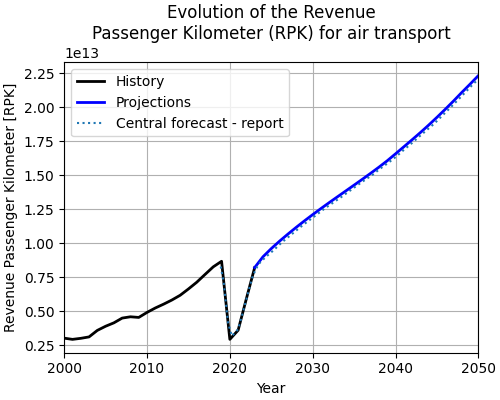

In [2]:
s1 = create_process(configuration_file="config_files/config_s1.yaml")
s1.compute()

plot_rpk = s1.plot("revenue_passenger_kilometer")
plot_rpk.ax.plot(
    central_years, np.array(central_rpk) * 1e12, ":", label="Central forecast - report"
)
plot_rpk.ax.legend()

Low and high traffic use the same central-year anchor and diverge afterwards (Phase 2's `alpha * central_growth(t)` construction), rather than a digitised report curve -- the third edition does not publish separate low/high traffic trajectories the way the second edition did.

    INFO - 18:22:48: Computing scenario: Low


    INFO - 18:22:48: Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


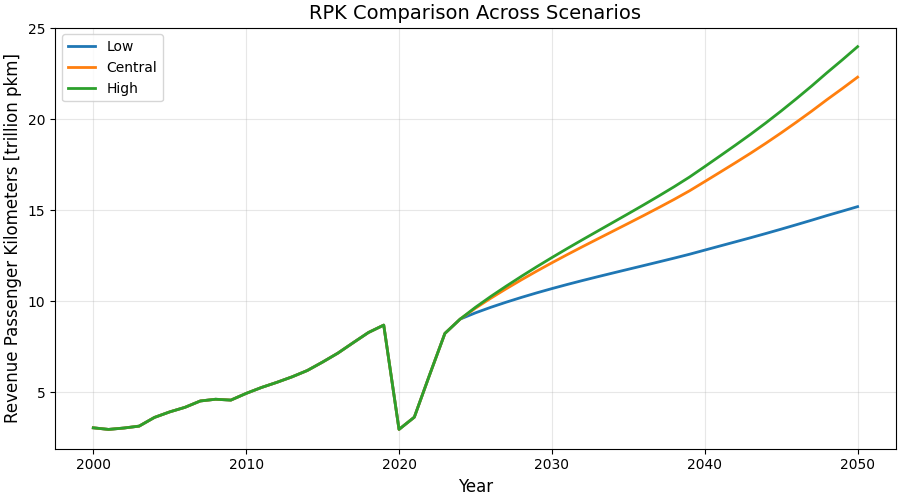

In [3]:
traffic_variants = assemble_processes(
    {
        "Low": create_process(configuration_file="config_files/config_s1-traffic-low.yaml"),
        "Central": s1,
        "High": create_process(configuration_file="config_files/config_s1-traffic-high.yaml"),
    }
)
traffic_variants.compute_all()
for process in traffic_variants:
    process.write_json()

traffic_variants.plot("rpk_comparison")

## Technology (full lifecycle)

Aircraft technology has significant improved since the commercialization of air travel, and efficiency gains have had a significant impact in reducing associated emissions.

Looking ahead, aircraft technology may continue with ever-modest efficiency gains, or adhere to disruptive technologies. We extract the CO2 emissions trajectory of 5 technological scenarios and fit annual efficiency gains based on these curbs.

    INFO - 18:22:57: Computing scenario: T0


    INFO - 18:22:57: Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: liquefaction_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: co2_dac_cost Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


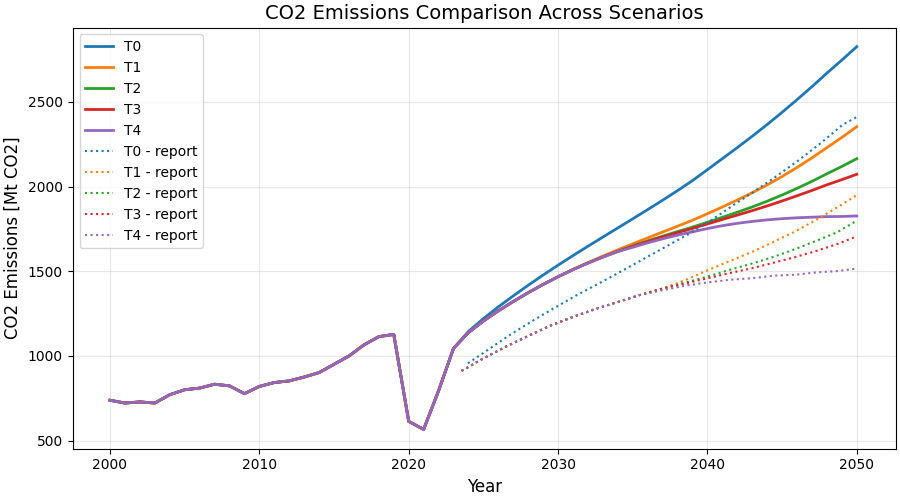

In [4]:
tech_variants = assemble_processes(
    {f"T{i}": create_process(configuration_file=f"config_files/config_t{i}.yaml") for i in range(5)}
)
tech_variants.compute_all()

# Persist these runs: their data_outputs/*.json are committed and read by the
# MyST document, but nothing else regenerates them, so they silently go stale
# whenever an input changes unless they are written here.
for process in tech_variants:
    process.write_json()

plot_co2 = tech_variants.plot("co2_emissions_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    plot_co2.ax.plot(
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
        ":",
        label=f"{scenario_name} - report",
    )
plot_co2.ax.legend()

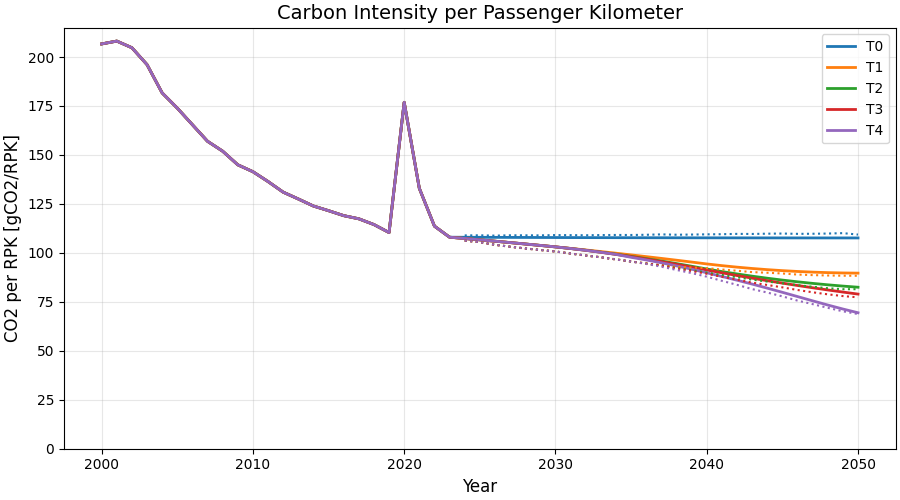

In [5]:
years_interp = np.arange(2024, 2051)

plot_co2_per_rpk = tech_variants.plot("co2_per_rpk_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    data_rpk = np.interp(years_interp, central_years, central_rpk)
    data_co2 = np.interp(
        years_interp,
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
    )
    plot_co2_per_rpk.ax.plot(
        years_interp, data_co2 / data_rpk, ":", label=f"{scenario_name} - report"
    )
plot_co2.ax.legend()


Compared to the 2nd edition, in the 3rd ed. all scenarios were revised with an additional 0.2% annual reduction in fuel burn in the 2019-2035 period, and in the T3 scenario (new configurations) after 2045 fuel burn annual reduction is lower (meaning aircraft will be less efficient) by 0.4%.

## Operations

The operations lever is a cumulative efficiency gain applied uniformly across the fleet, reaching 0.00 / 0.10 / 0.20 %/yr by 2050 for O1/O2/O3 -- values read directly from the report text (the highest-confidence provenance tier). S1 already runs at O3; O1 and O2 are computed here for comparison.

    INFO - 18:23:10: Computing scenario: O1 (0.00 %/yr)


    INFO - 18:23:10: Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


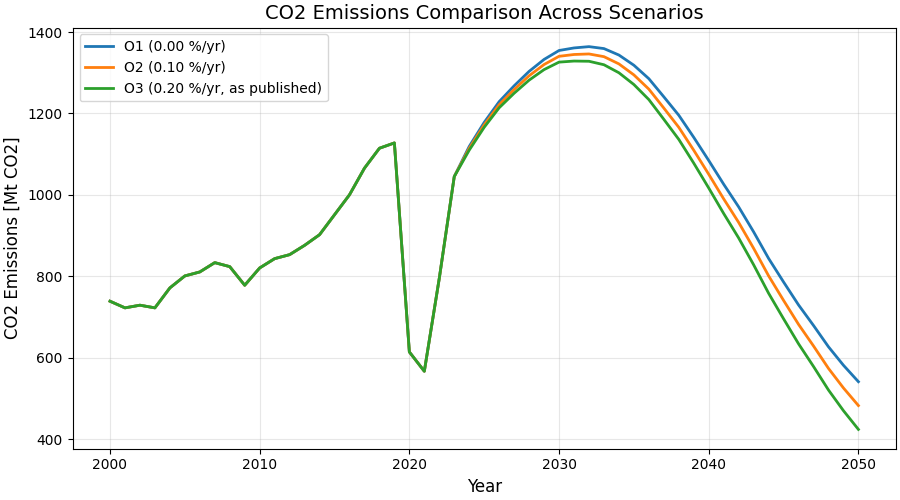

In [6]:
ops_variants = assemble_processes(
    {
        "O1 (0.00 %/yr)": create_process(configuration_file="config_files/config_s1.yaml"),
        "O2 (0.10 %/yr)": create_process(configuration_file="config_files/config_s1.yaml"),
        "O3 (0.20 %/yr, as published)": s1,
    }
)
ops_variants["O1 (0.00 %/yr)"].parameters.operations_gain_reference_years = [2020, 2050]
ops_variants["O1 (0.00 %/yr)"].parameters.operations_gain_reference_years_values = [0, 0]
ops_variants["O2 (0.10 %/yr)"].parameters.operations_gain_reference_years = [2020, 2050]
ops_variants["O2 (0.10 %/yr)"].parameters.operations_gain_reference_years_values = [0, 3]

ops_variants.compute_all()
ops_variants["O1 (0.00 %/yr)"].write_json(file_name="data_outputs/s1-ops-o1.json")
ops_variants["O2 (0.10 %/yr)"].write_json(file_name="data_outputs/s1-ops-o2.json")

ops_variants.plot("co2_emissions_comparison")

## Technology (CORSIA-like)

    INFO - 18:23:19: Computing scenario: T0


    INFO - 18:23:19: Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: liquefaction_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: co2_dac_cost Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


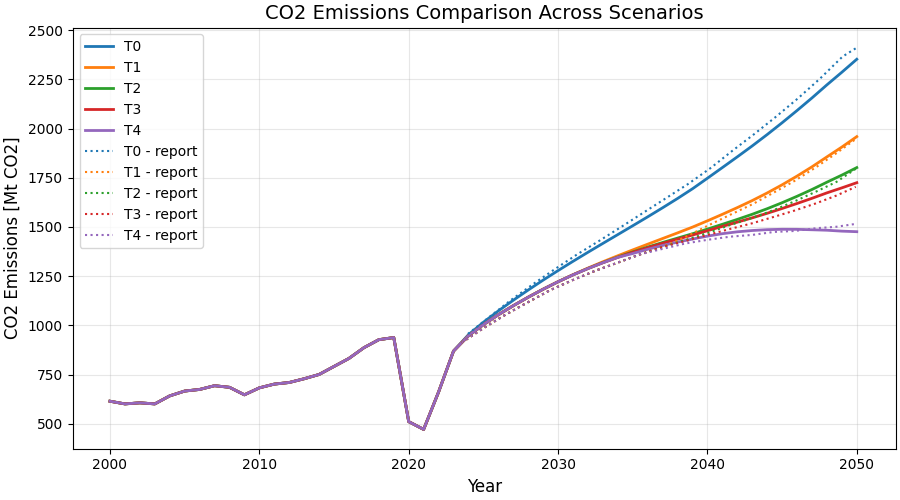

In [7]:
tech_variants_corsia = assemble_processes(
    {
        f"T{i}": create_process(configuration_file=f"config_files/config_t{i}-TTW.yaml")
        for i in range(5)
    }
)
tech_variants_corsia.compute_all()

# Persist these runs: their data_outputs/*.json are committed and read by the
# MyST document, but nothing else regenerates them, so they silently go stale
# whenever an input changes unless they are written here.
for process in tech_variants_corsia:
    process.write_json()

plot_co2_corsia = tech_variants_corsia.plot("co2_emissions_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    plot_co2_corsia.ax.plot(
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
        ":",
        label=f"{scenario_name} - report",
    )
plot_co2_corsia.ax.legend()

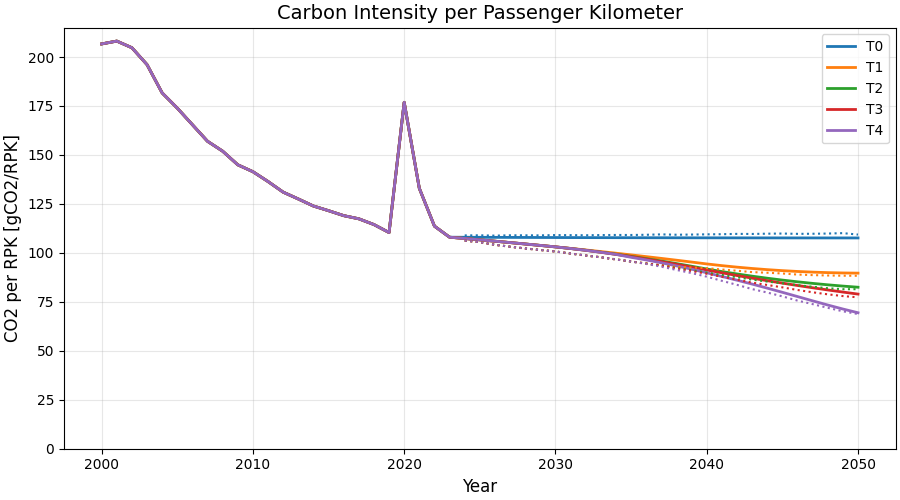

In [8]:
plot_co2_per_rpk_corsia = tech_variants.plot("co2_per_rpk_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    data_rpk = np.interp(years_interp, central_years, central_rpk)
    data_co2 = np.interp(
        years_interp,
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
    )
    plot_co2_per_rpk_corsia.ax.plot(
        years_interp, data_co2 / data_rpk, ":", label=f"{scenario_name} - report"
    )
plot_co2_corsia.ax.legend()

In [9]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals(), force_cleanup=False)

    INFO - 18:23:32: 🧹 clean_notebooks_on_tests called


    INFO - 18:23:32: ⏭ Skipping cleanup during notebook run
